In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/train.csv')

print(df.shape)
print(df.head())
print(df.isnull().sum())
df.info()
df.describe()

print(df['Churn'].value_counts(normalize=True).round(3))

(243787, 21)
   AccountAge  MonthlyCharges  TotalCharges SubscriptionType  \
0          20       11.055215    221.104302          Premium   
1          57        5.175208    294.986882            Basic   
2          73       12.106657    883.785952            Basic   
3          32        7.263743    232.439774            Basic   
4          57       16.953078    966.325422          Premium   

      PaymentMethod PaperlessBilling ContentType MultiDeviceAccess  \
0      Mailed check               No        Both                No   
1       Credit card              Yes      Movies                No   
2      Mailed check              Yes      Movies                No   
3  Electronic check               No    TV Shows                No   
4  Electronic check              Yes    TV Shows                No   

  DeviceRegistered  ViewingHoursPerWeek  ...  ContentDownloadsPerMonth  \
0           Mobile            36.758104  ...                        10   
1           Tablet            32.

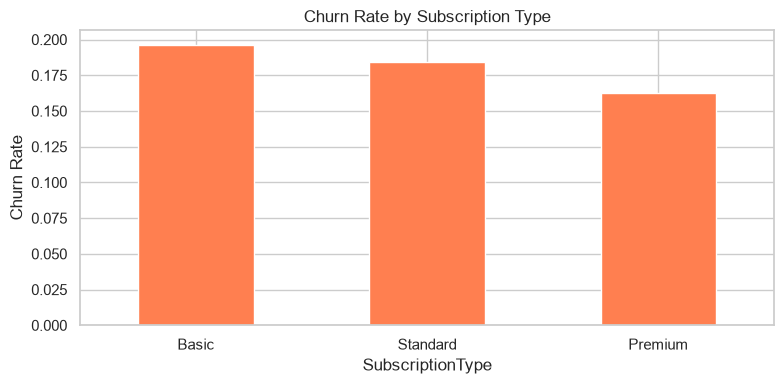

In [5]:
# Churn rate by subscription type
churn_by_sub = df.groupby('SubscriptionType')['Churn'].mean().sort_values(ascending=False)
churn_by_sub.plot(kind='bar', color='coral', figsize=(8, 4))
plt.title('Churn Rate by Subscription Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**What this might suggest**

Customers on the Basic plan may be more likely to churn than customers on the Premium plan. This could indicate that Premium customers perceive more value from the service, have greater engagement, or have stronger reasons to remain subscribed.

However, we shouldn't conclude that subscription type causes churn from this chart alone.

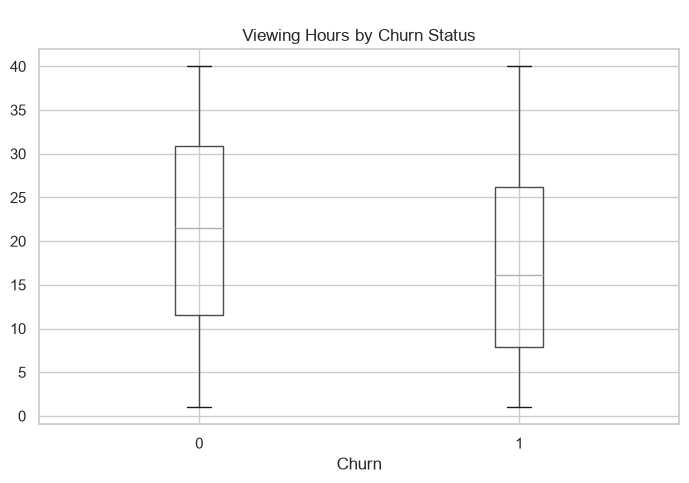

Churn
0    21.18
1    17.43
Name: ViewingHoursPerWeek, dtype: float64


In [6]:
# Do curners watch less content
df.boxplot(column='ViewingHoursPerWeek', by='Churn', figsize=(8, 5))
plt.title('Viewing Hours by Churn Status')
plt.suptitle(" ")
plt.show()

print(df.groupby('Churn')['ViewingHoursPerWeek'].mean().round(2))

Viewing Hours: Customers who churned had lower weekly viewing activity, with an average of 17.43 hours/week compared with 21.18 hours/week among customers who did not churn. The boxplot also shows a lower central tendency for churned customers. This suggests that lower engagement may be associated with a higher likelihood of churn. However, substantial overlap between the two groups indicates that viewing hours alone is unlikely to be sufficient for predicting churn.

In [7]:
# Account age comparison
print(df.groupby('Churn')['AccountAge'].mean().round(2))

# Support tickets
print(df.groupby('Churn')['SupportTicketsPerMonth'].mean().round(2))

Churn
0    63.27
1    45.67
Name: AccountAge, dtype: float64
Churn
0    4.39
1    5.02
Name: SupportTicketsPerMonth, dtype: float64


Customers who churn tend to have shorter account histories, lower viewing activity, and slightly higher support activity. These patterns suggest that customer tenure, engagement, and support interactions may be useful predictors of churn. However, the observed differences represent associations rather than causal relationships, and the predictive importance of these features should be evaluated using a machine learning model.